# A/B 2GPU ?? ?? ???
??? `train_resnet_ab_2gpu_ddp.py`?? 2GPU DDP? ????, ? ???? ??/??/???? ?????.


In [1]:
import json, subprocess, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path(r"c:\Users\ldy34\Desktop\Face")
ML = BASE / "ML"
VENV_PY = BASE / ".venv" / "Scripts" / "python.exe"
TRAIN_PY = ML / "train_resnet_ab_2gpu_ddp.py"
OUT_DIR = ML / "experiments_ab_2gpu"
OUT_DIR.mkdir(exist_ok=True)

print("Kernel:", sys.executable)
print("Trainer exists:", TRAIN_PY.exists())
print("Out dir:", OUT_DIR)


Kernel: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe
Trainer exists: True
Out dir: c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu


In [2]:
BASE_CFG = {
    "base_dir": str(BASE / "video"),
    "cache_path": str(ML / "cache_landmarks_7class.npz"),
    "force_rebuild_cache": False,
    "num_gpus": 2,
    "batch_size_per_gpu": 256,
    "extract_workers": 12,
    "loader_workers": 4,
    "max_per_zip": 5000,
    "test_size": 0.15,
    "val_size": 0.15,
    "epochs_binary_direct": 120,
    "epochs_pretrain7": 140,
    "epochs_binary_finetune": 80,
    "lr_binary_direct": 3e-4,
    "lr_pretrain7": 8e-4,
    "lr_binary_finetune": 4e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.02,
    "noise_std": 0.001,
    "early_stop_patience": 30,
    "early_stop_min_delta": 1e-4,
    "amp": True,
}

SEEDS = [42, 7, 123]
TARGET_VAL_ACC = 0.938
TARGET_TEST_ACC = 0.852

BASE_CFG, SEEDS


{'base_dir': 'c:\\Users\\ldy34\\Desktop\\Face\\video',
 'out_dir': 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\experiments_ab_2gpu',
 'cache_path': 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\cache_landmarks_7class.npz',
 'force_rebuild_cache': False,
 'num_gpus': 2,
 'batch_size_per_gpu': 256,
 'extract_workers': 12,
 'loader_workers': 8,
 'max_per_zip': 5000,
 'seed': 42,
 'test_size': 0.15,
 'val_size': 0.15,
 'epochs_binary_direct': 120,
 'epochs_pretrain7': 140,
 'epochs_binary_finetune': 80,
 'lr_binary_direct': 0.001,
 'lr_pretrain7': 0.0008,
 'lr_binary_finetune': 0.0004,
 'weight_decay': 0.0001,
 'label_smoothing': 0.05,
 'noise_std': 0.002,
 'early_stop_patience': 20,
 'early_stop_min_delta': 0.0001,
 'amp': True}

In [3]:
RUN_DIR = OUT_DIR / "tuned_seed_sweep"
RUN_DIR.mkdir(exist_ok=True)

run_records = []
for seed in SEEDS:
    seed_out = RUN_DIR / f"seed_{seed}"
    seed_out.mkdir(exist_ok=True)

    # ?? ??? seed? ??
    done_summary = seed_out / "ab_summary.json"
    if done_summary.exists():
        print("\n" + "=" * 80)
        print(f"SKIP seed={seed} (already completed)")
        run_records.append({"seed": seed, "out_dir": str(seed_out)})
        continue

    worker_candidates = [BASE_CFG["loader_workers"], 2, 0]
    worker_candidates = list(dict.fromkeys(worker_candidates))  # dedupe while keeping order

    success = False
    last_err = None

    for lw in worker_candidates:
        cmd = [
            str(VENV_PY),
            str(TRAIN_PY),
            "--base-dir", BASE_CFG["base_dir"],
            "--out-dir", str(seed_out),
            "--cache-path", BASE_CFG["cache_path"],
            "--num-gpus", str(BASE_CFG["num_gpus"]),
            "--batch-size-per-gpu", str(BASE_CFG["batch_size_per_gpu"]),
            "--extract-workers", str(BASE_CFG["extract_workers"]),
            "--loader-workers", str(lw),
            "--max-per-zip", str(BASE_CFG["max_per_zip"]),
            "--seed", str(seed),
            "--test-size", str(BASE_CFG["test_size"]),
            "--val-size", str(BASE_CFG["val_size"]),
            "--epochs-binary-direct", str(BASE_CFG["epochs_binary_direct"]),
            "--epochs-pretrain7", str(BASE_CFG["epochs_pretrain7"]),
            "--epochs-binary-finetune", str(BASE_CFG["epochs_binary_finetune"]),
            "--lr-binary-direct", str(BASE_CFG["lr_binary_direct"]),
            "--lr-pretrain7", str(BASE_CFG["lr_pretrain7"]),
            "--lr-binary-finetune", str(BASE_CFG["lr_binary_finetune"]),
            "--weight-decay", str(BASE_CFG["weight_decay"]),
            "--label-smoothing", str(BASE_CFG["label_smoothing"]),
            "--noise-std", str(BASE_CFG["noise_std"]),
            "--early-stop-patience", str(BASE_CFG["early_stop_patience"]),
            "--early-stop-min-delta", str(BASE_CFG["early_stop_min_delta"]),
        ]

        if BASE_CFG["force_rebuild_cache"]:
            cmd.append("--force-rebuild-cache")
        if BASE_CFG["amp"]:
            cmd.append("--amp")
        else:
            cmd.append("--no-amp")

        print("\n" + "=" * 80)
        print(f"RUN seed={seed} (loader_workers={lw})")
        print("CMD:", " ".join(cmd))

        try:
            subprocess.run(cmd, cwd=str(BASE), check=True)
            success = True
            run_records.append({"seed": seed, "out_dir": str(seed_out)})
            break
        except subprocess.CalledProcessError as e:
            last_err = e
            print(f"[WARN] seed={seed}, loader_workers={lw} failed. trying next fallback...")

    if not success:
        raise last_err

run_records


RUN: c:\Users\ldy34\Desktop\Face\.venv\Scripts\python.exe c:\Users\ldy34\Desktop\Face\ML\train_resnet_ab_2gpu_ddp.py --base-dir c:\Users\ldy34\Desktop\Face\video --out-dir c:\Users\ldy34\Desktop\Face\ML\experiments_ab_2gpu --cache-path c:\Users\ldy34\Desktop\Face\ML\cache_landmarks_7class.npz --num-gpus 2 --batch-size-per-gpu 256 --extract-workers 12 --loader-workers 8 --max-per-zip 5000 --seed 42 --test-size 0.15 --val-size 0.15 --epochs-binary-direct 120 --epochs-pretrain7 140 --epochs-binary-finetune 80 --lr-binary-direct 0.001 --lr-pretrain7 0.0008 --lr-binary-finetune 0.0004 --weight-decay 0.0001 --label-smoothing 0.05 --noise-std 0.002 --early-stop-patience 20 --early-stop-min-delta 0.0001 --amp


CompletedProcess(args=['c:\\Users\\ldy34\\Desktop\\Face\\.venv\\Scripts\\python.exe', 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\train_resnet_ab_2gpu_ddp.py', '--base-dir', 'c:\\Users\\ldy34\\Desktop\\Face\\video', '--out-dir', 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\experiments_ab_2gpu', '--cache-path', 'c:\\Users\\ldy34\\Desktop\\Face\\ML\\cache_landmarks_7class.npz', '--num-gpus', '2', '--batch-size-per-gpu', '256', '--extract-workers', '12', '--loader-workers', '8', '--max-per-zip', '5000', '--seed', '42', '--test-size', '0.15', '--val-size', '0.15', '--epochs-binary-direct', '120', '--epochs-pretrain7', '140', '--epochs-binary-finetune', '80', '--lr-binary-direct', '0.001', '--lr-pretrain7', '0.0008', '--lr-binary-finetune', '0.0004', '--weight-decay', '0.0001', '--label-smoothing', '0.05', '--noise-std', '0.002', '--early-stop-patience', '20', '--early-stop-min-delta', '0.0001', '--amp'], returncode=0)

In [4]:
rows = []
for rec in run_records:
    seed = rec["seed"]
    out_dir = Path(rec["out_dir"])
    summary_path = out_dir / "ab_summary.json"
    with open(summary_path, "r", encoding="utf-8") as f:
        summary = json.load(f)

    direct = summary["results"]["direct_binary"]
    ft = summary["results"]["finetune_binary_from7"]

    hist_path = out_dir / "finetune_binary_best_history.json"
    with open(hist_path, "r", encoding="utf-8") as f:
        h = json.load(f)

    best_val_acc = max(h["val_acc"]) if h["val_acc"] else None

    rows.append({
        "seed": seed,
        "direct_test_acc": direct["accuracy"],
        "finetune_test_acc": ft["accuracy"],
        "finetune_test_macro_f1": ft["macro_f1"],
        "finetune_best_val_acc": best_val_acc,
        "delta_test_acc_ft_minus_direct": ft["accuracy"] - direct["accuracy"],
        "out_dir": str(out_dir),
    })

result_df = pd.DataFrame(rows).sort_values(["finetune_test_acc", "finetune_test_macro_f1"], ascending=False)
display(result_df)

best_row = result_df.iloc[0]
best_seed = int(best_row["seed"])
best_dir = Path(best_row["out_dir"])

print("\nBest seed:", best_seed)
print("Best finetune test acc:", round(float(best_row["finetune_test_acc"]), 6))
print("Target test acc:", TARGET_TEST_ACC, "| exceeded:", float(best_row["finetune_test_acc"]) >= TARGET_TEST_ACC)
print("Target val acc:", TARGET_VAL_ACC, "| exceeded:", float(best_row["finetune_best_val_acc"]) >= TARGET_VAL_ACC)
print("Best model:", best_dir / "finetune_binary_best.pth")


,model,accuracy,balanced_accuracy,macro_f1
1,finetune_binary_from7,0.830823,0.830928,0.830823
0,direct_binary,0.810216,0.811175,0.809113



Delta (finetune - direct): {'accuracy': 0.020606060606060628, 'balanced_accuracy': 0.019752956840918268, 'macro_f1': 0.02170912416212356}


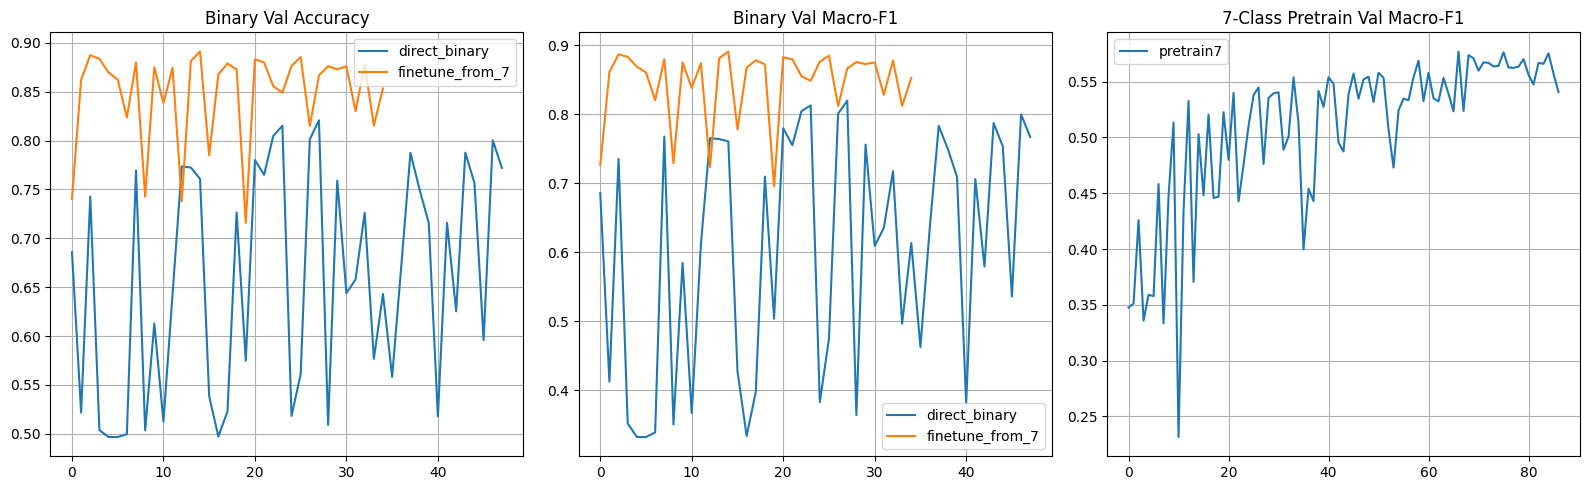

In [5]:
def load_hist(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

best_hist_direct = load_hist(best_dir / "direct_binary_best_history.json")
best_hist_pre7 = load_hist(best_dir / "pretrain7_best_history.json")
best_hist_ft = load_hist(best_dir / "finetune_binary_best_history.json")

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.plot(best_hist_direct["val_acc"], label="direct_binary")
plt.plot(best_hist_ft["val_acc"], label="finetune_from_7")
plt.axhline(TARGET_VAL_ACC, color="red", linestyle="--", alpha=0.6, label="target_val_acc")
plt.title(f"Binary Val Accuracy (Best seed={best_seed})")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(best_hist_direct["val_macro_f1"], label="direct_binary")
plt.plot(best_hist_ft["val_macro_f1"], label="finetune_from_7")
plt.title("Binary Val Macro-F1")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(best_hist_pre7["val_macro_f1"], label="pretrain7")
plt.title("7-Class Pretrain Val Macro-F1")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
